# 🧠 Depression Detection — Deep Learning Pipeline
**Dataset:** `mental_health_combined_test.csv`  
**Target:** `label` (0 = Not Depressed · 1 = Depressed)  
**Split:** 70% Train | 15% Validation | 15% Test  
**Models:** BERT · RoBERTa · DistilBERT · RoBERTa-LSTM · XLM-RoBERTa · Hybrid BERT+RoBERTa Fusion  


## 📦 Step 1 — Install Required Packages

In [1]:
import subprocess, sys

pkgs = [
    "transformers==4.40.0",
    "torch",
    "emoji",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "tqdm",
    "accelerate",
]

for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ All packages installed!")


✅ All packages installed!


## 📚 Step 2 — Import Libraries

In [2]:
import re, warnings, os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import emoji
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast

from transformers import (
    AutoTokenizer, AutoModel,
    BertTokenizer,    BertModel,
    RobertaTokenizer, RobertaModel,
    DistilBertTokenizer, DistilBertModel,
    XLMRobertaTokenizer, XLMRobertaModel,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries imported! | Device: {DEVICE}")


c:\Users\Adnan Baqi\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported! | Device: cuda


## 📂 Step 3 — Upload / Load Dataset

In [3]:
import os

CSV_PATH = "mental_health_combined_test.csv"

if os.path.exists(CSV_PATH):
    print(f"✅ File found: {CSV_PATH}")
else:
    raise FileNotFoundError(f"❌ File not found: {CSV_PATH}")

✅ File found: mental_health_combined_test.csv


## 🔍 Step 4 — Load & Inspect Data

In [4]:
df = pd.read_csv(CSV_PATH)
print("📊 Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head(3))

TEXT_COL  = "text"
LABEL_COL = "label"

print("\n🏷️ Label distribution:")
print(df[LABEL_COL].value_counts())

df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
print(f"\n✅ After dropping nulls: {df.shape[0]} rows")


📊 Dataset shape: (27977, 2)

Columns: ['text', 'label']


,text,label
0,dear american teens question dutch person hear...,0
1,nothing look forward lifei dont many reasons k...,1
2,music recommendations im looking expand playli...,0



🏷️ Label distribution:
label
0    14139
1    13838
Name: count, dtype: int64

✅ After dropping nulls: 27977 rows


## 🧹 Step 5 — Emoji-Aware Text Cleaning

In [5]:
def emoji_to_text(text: str) -> str:
    return emoji.demojize(text, delimiters=(" ", " "))

def clean_tweet(text: str) -> str:
    text = str(text)
    text = emoji_to_text(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"@\w+", " user ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    text = re.sub(r"&amp;", " and ", text)
    text = re.sub(r"[^a-z\s_]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[TEXT_COL].apply(clean_tweet)
print("✅ Cleaning done. Sample comparison:")
display(df[[TEXT_COL, "clean_text"]].head(5))


✅ Cleaning done. Sample comparison:


,text,clean_text
0,dear american teens question dutch person hear...,dear american teens question dutch person hear...
1,nothing look forward lifei dont many reasons k...,nothing look forward lifei dont many reasons k...
2,music recommendations im looking expand playli...,music recommendations im looking expand playli...
3,im done trying feel betterthe reason im still ...,im done trying feel betterthe reason im still ...
4,worried year old girl subject domestic physic...,worried year old girl subject domestic physica...


## ✂️ Step 6 — Train / Validation / Test Split (70-15-15)

✅ Train  : 19,583 samples  (70.0%)
   Val    :  4,197 samples  (15.0%)
   Test   :  4,197 samples  (15.0%)


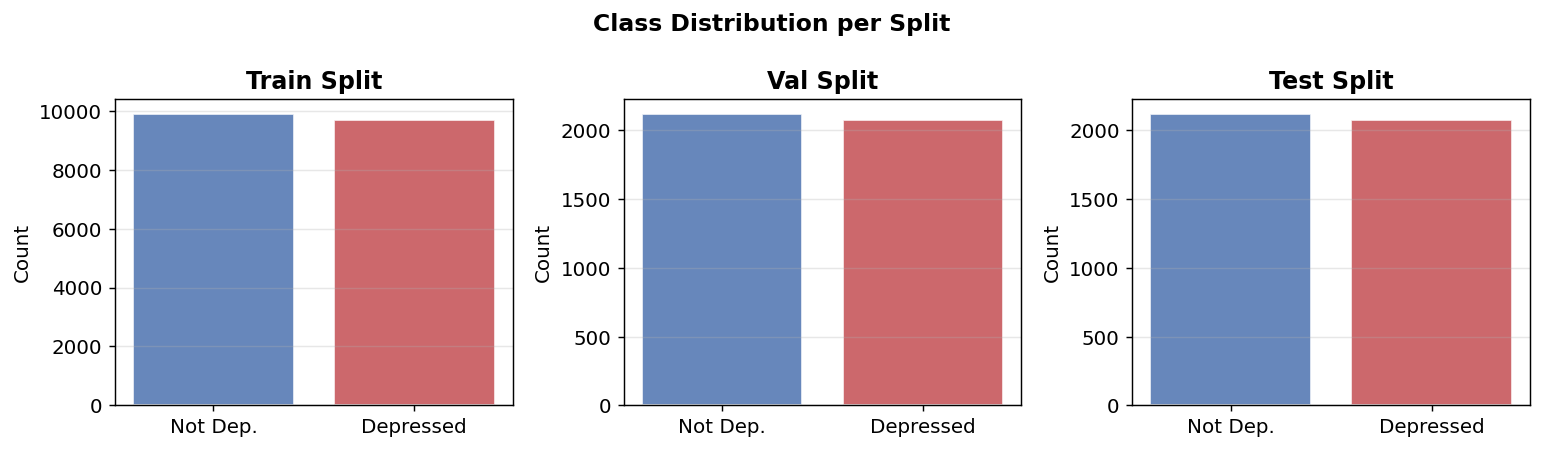

In [6]:
X = df["clean_text"].values
y = df[LABEL_COL].astype(int).values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"✅ Train  : {len(X_train):>6,} samples  ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Val    : {len(X_val):>6,} samples  ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test   : {len(X_test):>6,} samples  ({len(X_test)/len(X)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (split_y, split_name) in zip(axes, [(y_train,"Train"),(y_val,"Val"),(y_test,"Test")]):
    vals = pd.Series(split_y).value_counts().sort_index()
    ax.bar(["Not Dep.", "Depressed"], vals.values,
           color=["#4C72B0","#C44E52"], edgecolor="white", alpha=0.85)
    ax.set_title(f"{split_name} Split", fontweight="bold")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Class Distribution per Split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## ⚙️ Step 7 — Training Configuration

In [7]:
# ── Hyperparameters ──────────────────────────────────────────────────
MAX_LEN      = 128      # token length
BATCH_SIZE   = 32       # increased from 4 → stable gradients, less overfitting
EPOCHS       = 5
LR           = 2e-5     # AdamW learning rate
WARMUP_RATIO = 0.1
DROPOUT      = 0.3      # classifier head dropout
PATIENCE     = 2        # early stopping patience

MODEL_CONFIGS = {
    "BERT":               "bert-base-uncased",
    "RoBERTa":            "roberta-base",
    "DistilBERT":         "distilbert-base-uncased",
    "RoBERTa-LSTM":       "roberta-base",
    "XLM-RoBERTa":        "xlm-roberta-base",
    "Hybrid BERT+RoBERTa":"bert-base-uncased",
}

COLORS = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860"]
print("✅ Config ready.")
for k, v in MODEL_CONFIGS.items():
    print(f"   {k:<30} → {v}")


✅ Config ready.
   BERT                           → bert-base-uncased
   RoBERTa                        → roberta-base
   DistilBERT                     → distilbert-base-uncased
   RoBERTa-LSTM                   → roberta-base
   XLM-RoBERTa                    → xlm-roberta-base
   Hybrid BERT+RoBERTa            → bert-base-uncased


## 🗂️ Step 8 — PyTorch Dataset & DataLoader Utilities

In [8]:
class TextDataset(Dataset):
    """Single-tokenizer dataset used by BERT, RoBERTa, DistilBERT, XLM-RoBERTa."""
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "token_type_ids": enc.get("token_type_ids", torch.zeros(self.max_len, dtype=torch.long)).squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


class DualTextDataset(Dataset):
    """Dual-tokenizer dataset for the Hybrid BERT+RoBERTa fusion model."""
    def __init__(self, texts, labels, tok_a, tok_b, max_len=MAX_LEN):
        self.texts  = texts
        self.labels = labels
        self.tok_a  = tok_a
        self.tok_b  = tok_b
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        def enc(tok, text):
            e = tok(text, max_length=self.max_len, padding="max_length",
                    truncation=True, return_tensors="pt")
            return {
                "input_ids":      e["input_ids"].squeeze(0),
                "attention_mask": e["attention_mask"].squeeze(0),
                "token_type_ids": e.get("token_type_ids",
                                        torch.zeros(self.max_len, dtype=torch.long)).squeeze(0),
            }
        ea = enc(self.tok_a, self.texts[idx])
        eb = enc(self.tok_b, self.texts[idx])
        return {
            "a_input_ids":      ea["input_ids"],
            "a_attention_mask": ea["attention_mask"],
            "a_token_type_ids": ea["token_type_ids"],
            "b_input_ids":      eb["input_ids"],
            "b_attention_mask": eb["attention_mask"],
            "b_token_type_ids": eb["token_type_ids"],
            "label":            torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=False):
    return DataLoader(dataset, batch_size=batch_size,
                      shuffle=shuffle, num_workers=0, pin_memory=True)

print("✅ Dataset classes defined.")


✅ Dataset classes defined.


## 🏗️ Step 9 — Model Architecture Definitions

In [9]:
# ─── 1. Standard Transformer Classifier ──────────────────────────────
class TransformerClassifier(nn.Module):
    """Generic [CLS]-token → dropout → linear head."""
    def __init__(self, model_name, num_labels=2, dropout=DROPOUT):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        hidden        = self.encoder.config.hidden_size
        self.drop     = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # DistilBERT has no token_type_ids
        kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
        if token_type_ids is not None and hasattr(self.encoder.config, "type_vocab_size"):
            kwargs["token_type_ids"] = token_type_ids
        out   = self.encoder(**kwargs)
        # CLS token: [batch, hidden]
        cls   = out.last_hidden_state[:, 0, :]
        logits = self.classifier(self.drop(cls))
        return logits


# ─── 2. RoBERTa-LSTM Classifier ──────────────────────────────────────
class RoBERTaLSTMClassifier(nn.Module):
    """RoBERTa token embeddings fed into a BiLSTM, then classified."""
    def __init__(self, model_name="roberta-base", num_labels=2,
                 lstm_hidden=256, lstm_layers=1, dropout=DROPOUT):
        super().__init__()
        self.encoder = RobertaModel.from_pretrained(model_name)
        hidden       = self.encoder.config.hidden_size
        self.lstm    = nn.LSTM(
            input_size=hidden,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.drop       = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)   # *2 for bidirectional

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq    = out.last_hidden_state          # [batch, seq_len, hidden]
        lstm_out, _ = self.lstm(seq)            # [batch, seq_len, lstm_hidden*2]
        # Mean-pool over non-padding positions for better sequence representation
        mask   = attention_mask.unsqueeze(-1).float()  # [batch, seq, 1]
        pooled = (lstm_out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        logits = self.classifier(self.drop(pooled))
        return logits


# ─── 3. Hybrid BERT + RoBERTa Fusion Classifier ───────────────────────
class HybridFusionClassifier(nn.Module):
    """
    Concatenates [CLS] from BERT and [CLS] from RoBERTa,
    then passes through a shared MLP head.
    """
    def __init__(self, bert_name="bert-base-uncased",
                 roberta_name="roberta-base",
                 num_labels=2, dropout=DROPOUT):
        super().__init__()
        self.bert    = BertModel.from_pretrained(bert_name)
        self.roberta = RobertaModel.from_pretrained(roberta_name)
        h_b = self.bert.config.hidden_size
        h_r = self.roberta.config.hidden_size
        self.drop    = nn.Dropout(dropout)
        self.head    = nn.Sequential(
            nn.Linear(h_b + h_r, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_labels),
        )

    def forward(self,
                a_input_ids, a_attention_mask, a_token_type_ids,
                b_input_ids, b_attention_mask, b_token_type_ids=None):
        cls_b = self.bert(
            input_ids=a_input_ids,
            attention_mask=a_attention_mask,
            token_type_ids=a_token_type_ids,
        ).last_hidden_state[:, 0, :]
        cls_r = self.roberta(
            input_ids=b_input_ids,
            attention_mask=b_attention_mask,
        ).last_hidden_state[:, 0, :]
        fused  = torch.cat([cls_b, cls_r], dim=-1)
        logits = self.head(self.drop(fused))
        return logits


print("✅ Model architectures defined:")
print("   • TransformerClassifier  (BERT, RoBERTa, DistilBERT, XLM-RoBERTa)")
print("   • RoBERTaLSTMClassifier  (RoBERTa + BiLSTM)")
print("   • HybridFusionClassifier (BERT ⊕ RoBERTa fusion)")


✅ Model architectures defined:
   • TransformerClassifier  (BERT, RoBERTa, DistilBERT, XLM-RoBERTa)
   • RoBERTaLSTMClassifier  (RoBERTa + BiLSTM)
   • HybridFusionClassifier (BERT ⊕ RoBERTa fusion)


## 🔁 Step 10 — Training & Evaluation Loop

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ─────────────────────────────────────────────
# ✅ Utility: Move batch to device safely
# ─────────────────────────────────────────────
def move_batch(batch):
    return {
        k: v.to(DEVICE, non_blocking=True) if isinstance(v, torch.Tensor) else v
        for k, v in batch.items()
    }


# ─────────────────────────────────────────────
# 🚀 TRAIN FUNCTION (FIXED)
# ─────────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, scaler, hybrid=False):
    model.train()

    total_loss, correct, n = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    for batch in loader:
        batch = move_batch(batch)   # ✅ FIX (critical)

        optimizer.zero_grad()
        labels = batch["label"]

        with autocast(enabled=(DEVICE.type == "cuda")):
            if hybrid:
                logits = model(
                    a_input_ids      = batch["a_input_ids"],
                    a_attention_mask = batch["a_attention_mask"],
                    a_token_type_ids = batch["a_token_type_ids"],
                    b_input_ids      = batch["b_input_ids"],
                    b_attention_mask = batch["b_attention_mask"],
                )
            else:
                logits = model(
                    input_ids      = batch["input_ids"],
                    attention_mask = batch["attention_mask"],
                    token_type_ids = batch.get("token_type_ids", None),
                )

            loss = criterion(logits, labels)

        # ✅ Mixed precision + stability
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * len(labels)

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        n += len(labels)

    return total_loss / n, correct / n


# ─────────────────────────────────────────────
# 🧪 EVALUATION FUNCTION (FIXED)
# ─────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, return_probs=False, hybrid=False):
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    criterion = nn.CrossEntropyLoss()

    total_loss, n = 0.0, 0

    for batch in loader:
        batch = move_batch(batch)   # ✅ FIX (critical)

        labels = batch["label"]

        if hybrid:
            logits = model(
                a_input_ids      = batch["a_input_ids"],
                a_attention_mask = batch["a_attention_mask"],
                a_token_type_ids = batch["a_token_type_ids"],
                b_input_ids      = batch["b_input_ids"],
                b_attention_mask = batch["b_attention_mask"],
            )
        else:
            logits = model(
                input_ids      = batch["input_ids"],
                attention_mask = batch["attention_mask"],
                token_type_ids = batch.get("token_type_ids", None),
            )

        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * len(labels)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

        n += len(labels)

    metrics = dict(
        loss      = total_loss / n,
        accuracy  = accuracy_score(all_labels, all_preds),
        precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0),
        recall    = recall_score(all_labels, all_preds, average="weighted", zero_division=0),
        f1        = f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        roc_auc   = roc_auc_score(all_labels, all_probs),
        preds     = all_preds,
        probs     = all_probs,
        labels    = all_labels,
    )

    return metrics


print("training + evaluation pipeline ready ")

training + evaluation pipeline ready 


## 🚀 Step 11 — Train All 6 Models

In [11]:
# ── Live Training Visualisation Helper ──────────────────────────────
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def live_plot(model_name, history, epoch, total_epochs, val_metrics, final_met_so_far):
    """
    Called after every epoch. Shows:
      Row 1 : loss curve + accuracy curve for current model
      Row 2 : live val F1/Precision/Recall for current model
      Row 3 : bar chart of best test metrics for all finished models
    """
    clear_output(wait=True)
    epochs_so_far = list(range(1, epoch + 1))

    n_done   = len(final_met_so_far)
    fig      = plt.figure(figsize=(18, 4 + max(n_done, 1) * 0.9 + 3))
    gs       = gridspec.GridSpec(
        3, 3,
        height_ratios=[3, 3, max(n_done * 0.8, 2)],
        hspace=0.55, wspace=0.35
    )

    col = COLORS[list(MODEL_CONFIGS.keys()).index(model_name) % len(COLORS)]

    # ── Row 0: Loss & Accuracy ──────────────────────────────────────
    ax_loss = fig.add_subplot(gs[0, 0])
    ax_loss.plot(epochs_so_far, history['train_loss'], 'o--', color=col, label='Train', lw=2)
    ax_loss.plot(epochs_so_far, history['val_loss'],   's-',  color=col, label='Val',   lw=2, alpha=0.6)
    ax_loss.set_title(f'{model_name}  —  Loss', fontweight='bold', fontsize=10)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)
    ax_loss.set_xticks(epochs_so_far)

    ax_acc = fig.add_subplot(gs[0, 1])
    ax_acc.plot(epochs_so_far, [a*100 for a in history['train_acc']], 'o--', color=col, label='Train', lw=2)
    ax_acc.plot(epochs_so_far, [a*100 for a in history['val_acc']],   's-',  color=col, label='Val',   lw=2, alpha=0.6)
    ax_acc.set_title(f'{model_name}  —  Accuracy', fontweight='bold', fontsize=10)
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Acc (%)')
    ax_acc.set_ylim(0, 105); ax_acc.legend(fontsize=8); ax_acc.grid(True, alpha=0.3)
    ax_acc.set_xticks(epochs_so_far)

    # ── Row 0 col 2: epoch status card ─────────────────────────────
    ax_stat = fig.add_subplot(gs[0, 2])
    ax_stat.axis('off')
    status_txt = (
        f"Model   : {model_name}\n"
        f"Epoch   : {epoch} / {total_epochs}\n"
        f"─────────────────────\n"
        f"Val Loss      : {val_metrics['loss']:.4f}\n"
        f"Val Accuracy  : {val_metrics['accuracy']*100:.2f}%\n"
        f"Val F1        : {val_metrics['f1']:.4f}\n"
        f"Val Precision : {val_metrics['precision']:.4f}\n"
        f"Val Recall    : {val_metrics['recall']:.4f}\n"
        f"Val ROC-AUC   : {val_metrics['roc_auc']:.4f}"
    )
    ax_stat.text(0.05, 0.95, status_txt, transform=ax_stat.transAxes,
                 fontsize=10, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#eef2ff', alpha=0.8))

    # ── Row 1: F1 / Precision / Recall curve ────────────────────────
    ax_f1 = fig.add_subplot(gs[1, 0])
    ax_f1.plot(epochs_so_far, history['val_f1'],        'o-',  color='#4C72B0', label='F1',        lw=2)
    ax_f1.plot(epochs_so_far, history['val_precision'], 's--', color='#DD8452', label='Precision', lw=2)
    ax_f1.plot(epochs_so_far, history['val_recall'],    '^:',  color='#55A868', label='Recall',    lw=2)
    ax_f1.set_title(f'{model_name}  —  Val Metrics', fontweight='bold', fontsize=10)
    ax_f1.set_xlabel('Epoch'); ax_f1.set_ylabel('Score')
    ax_f1.set_ylim(0, 1.05); ax_f1.legend(fontsize=8); ax_f1.grid(True, alpha=0.3)
    ax_f1.set_xticks(epochs_so_far)

    # ── Row 1 col 1-2: overfitting gap gauge ────────────────────────
    ax_gap = fig.add_subplot(gs[1, 1:])
    gaps   = [tr - vl for tr, vl in zip(history['train_acc'], history['val_acc'])]
    bar_colors = ['#C44E52' if g > 0.08 else '#55A868' for g in gaps]
    ax_gap.bar(epochs_so_far, [g*100 for g in gaps], color=bar_colors, alpha=0.8, edgecolor='white')
    ax_gap.axhline(8, color='#C44E52', ls='--', lw=1.2, label='Overfit threshold (8%)')
    ax_gap.set_title('Train–Val Accuracy Gap  (overfit detector)', fontweight='bold', fontsize=10)
    ax_gap.set_xlabel('Epoch'); ax_gap.set_ylabel('Gap (%)')
    ax_gap.legend(fontsize=8); ax_gap.grid(True, alpha=0.3)
    ax_gap.set_xticks(epochs_so_far)

    # ── Row 2: Live leaderboard of finished models ───────────────────
    ax_lb = fig.add_subplot(gs[2, :])
    if final_met_so_far:
        names  = list(final_met_so_far.keys())
        f1s    = [final_met_so_far[m]['F1-Score'] for m in names]
        aucs   = [final_met_so_far[m]['ROC-AUC']  for m in names]
        accs   = [final_met_so_far[m]['Accuracy']  for m in names]
        x      = range(len(names))
        w      = 0.25
        ax_lb.bar([i - w for i in x], accs, w, label='Accuracy', color='#4C72B0', alpha=0.8)
        ax_lb.bar(x,                  f1s,  w, label='F1',       color='#55A868', alpha=0.8)
        ax_lb.bar([i + w for i in x], aucs, w, label='ROC-AUC',  color='#DD8452', alpha=0.8)
        for i, (a, f, u) in enumerate(zip(accs, f1s, aucs)):
            ax_lb.text(i - w, a + 0.005, f'{a:.3f}', ha='center', va='bottom', fontsize=7)
            ax_lb.text(i,     f + 0.005, f'{f:.3f}', ha='center', va='bottom', fontsize=7)
            ax_lb.text(i + w, u + 0.005, f'{u:.3f}', ha='center', va='bottom', fontsize=7)
        ax_lb.set_xticks(list(x))
        ax_lb.set_xticklabels(names, fontsize=9, rotation=10, ha='right')
        ax_lb.set_ylim(0, 1.12)
        ax_lb.set_ylabel('Score')
        ax_lb.set_title('🏆 Live Leaderboard — Completed Models (Test Set)', fontweight='bold', fontsize=11)
        ax_lb.legend(fontsize=9); ax_lb.grid(axis='y', alpha=0.3)
    else:
        ax_lb.text(0.5, 0.5, 'Leaderboard will appear after first model finishes',
                   ha='center', va='center', fontsize=12, color='gray')
        ax_lb.axis('off')

    plt.suptitle(f'Live Training Progress  ·  {model_name}  ·  Epoch {epoch}/{total_epochs}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

print('✅ live_plot() ready')


✅ live_plot() ready


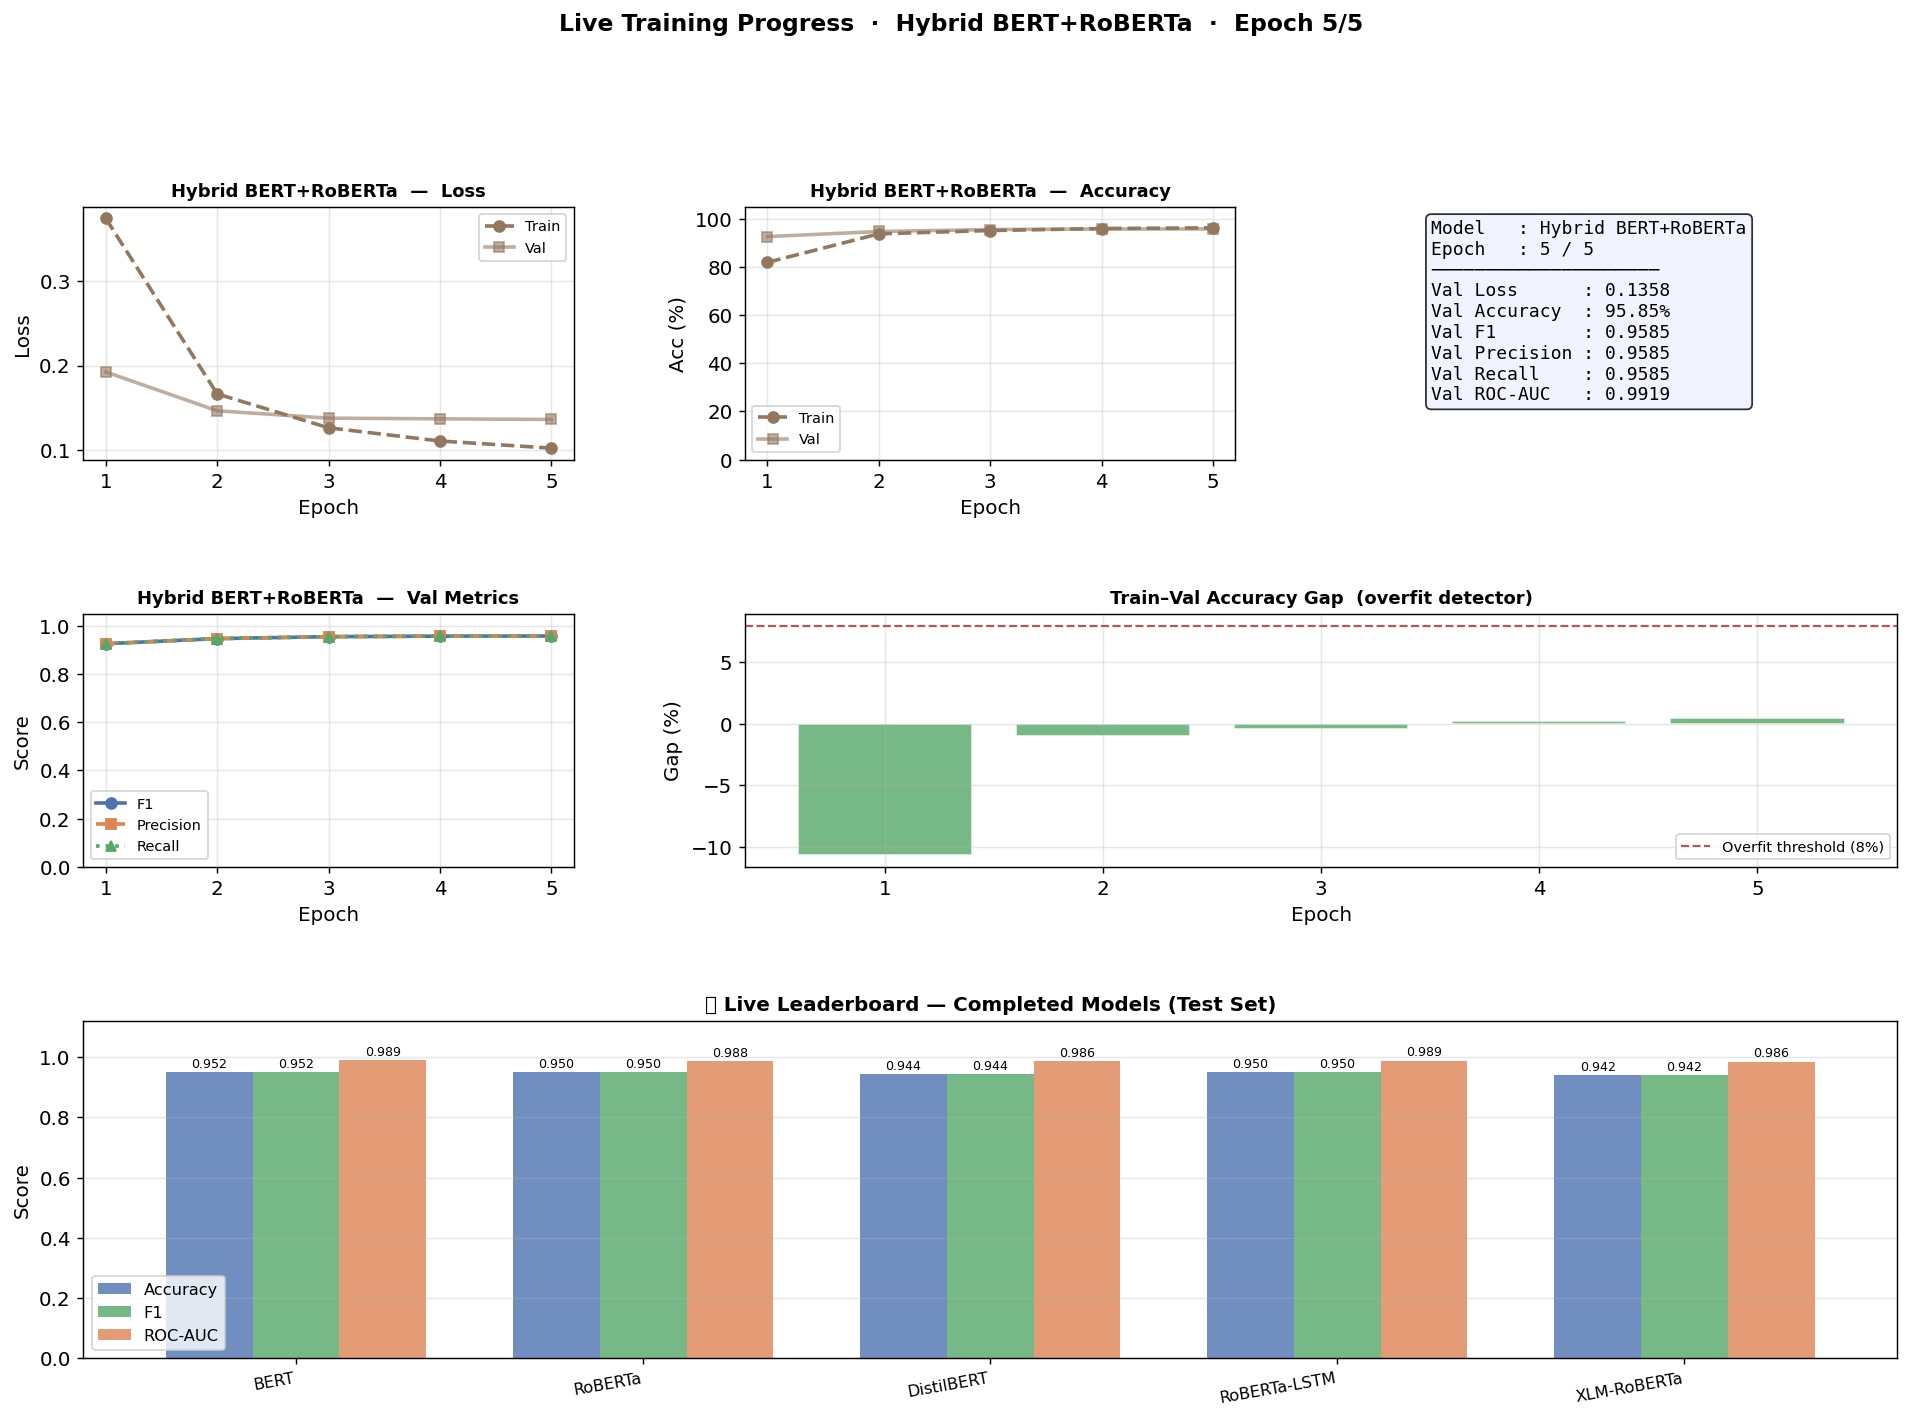

  ✔ TEST → Acc=0.9557  F1=0.9557  ROC-AUC=0.9904  | Total: 3036.8s

🎉 All 6 models trained!


In [12]:
results    = {}   # per-model epoch history + final test metrics
final_met  = {}   # compact table

# ─── Helper to build a fresh model ────────────────────────────────────
def build_model(name, config_name):
    if name == "RoBERTa-LSTM":
        return RoBERTaLSTMClassifier(config_name).to(DEVICE)
    elif name == "Hybrid BERT+RoBERTa":
        return HybridFusionClassifier(
            bert_name="bert-base-uncased",
            roberta_name="roberta-base"
        ).to(DEVICE)
    else:
        return TransformerClassifier(config_name).to(DEVICE)


for model_name, config_name in MODEL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"▶  Training: {model_name}")
    print(f"{'='*60}")

    is_hybrid = (model_name == "Hybrid BERT+RoBERTa")

    # ── Tokenizer(s) ──────────────────────────────────────────
    if is_hybrid:
        tok_a = BertTokenizer.from_pretrained("bert-base-uncased")
        tok_b = RobertaTokenizer.from_pretrained("roberta-base")
        train_ds = DualTextDataset(X_train, y_train, tok_a, tok_b)
        val_ds   = DualTextDataset(X_val,   y_val,   tok_a, tok_b)
        test_ds  = DualTextDataset(X_test,  y_test,  tok_a, tok_b)
    else:
        tok = AutoTokenizer.from_pretrained(config_name)
        train_ds = TextDataset(X_train, y_train, tok)
        val_ds   = TextDataset(X_val,   y_val,   tok)
        test_ds  = TextDataset(X_test,  y_test,  tok)

    train_loader = make_loader(train_ds, shuffle=True)
    val_loader   = make_loader(val_ds)
    test_loader  = make_loader(test_ds)

    # ── Model / optimizer / scheduler ─────────────────────────
    model     = build_model(model_name, config_name)
    # ── Layer-wise learning rate decay ─────────────────────────────────
    no_decay  = ["bias", "LayerNorm.weight"]
    optimizer_params = [
        # Encoder layers: lower LR to avoid destroying pre-trained weights
        {"params": [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay) and "classifier" not in n and "head" not in n and "lstm" not in n],
         "lr": LR * 0.1, "weight_decay": 0.01},
        {"params": [p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay) and "classifier" not in n and "head" not in n and "lstm" not in n],
         "lr": LR * 0.1, "weight_decay": 0.0},
        # Classifier / LSTM head: full LR
        {"params": [p for n, p in model.named_parameters()
                    if "classifier" in n or "head" in n or "lstm" in n],
         "lr": LR, "weight_decay": 0.01},
    ]
    optimizer = AdamW(optimizer_params)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = int(total_steps * WARMUP_RATIO),
        num_training_steps = total_steps,
    )
    scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

    history = dict(
        train_loss=[], train_acc=[],
        val_loss=[],   val_acc=[],
        val_f1=[],     val_precision=[], val_recall=[]
    )

    best_val_f1    = -1
    best_state     = None
    patience_count = 0
    model_start    = time.time()

    for epoch in range(1, EPOCHS + 1):
        ep_start   = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer,
                                      scheduler, scaler, hybrid=is_hybrid)
        val_metrics     = evaluate(model, val_loader, hybrid=is_hybrid)
        ep_time = time.time() - ep_start

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])

        print(f"  Epoch {epoch}/{EPOCHS}  |  "
              f"Train Loss={tr_loss:.4f}  Acc={tr_acc:.4f}  |  "
              f"Val Loss={val_metrics['loss']:.4f}  "
              f"F1={val_metrics['f1']:.4f}  "
              f"[{ep_time:.1f}s]")

        # ── Live plot after every epoch ─────────────────────────
        live_plot(model_name, history, epoch, EPOCHS, val_metrics, final_met)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1    = val_metrics["f1"]
            best_state     = {k: v.cpu() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"  ⏹ Early stopping at epoch {epoch} (no val F1 improvement for {PATIENCE} epochs)")
                break

    # Load best checkpoint for test evaluation
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    test_metrics = evaluate(model, test_loader, hybrid=is_hybrid)
    total_time   = time.time() - model_start

    results[model_name] = {
        "history":  history,
        "y_pred":   test_metrics["preds"],
        "y_prob":   test_metrics["probs"],
        "y_true":   test_metrics["labels"],
    }

    final_met[model_name] = {
        "Accuracy":  round(test_metrics["accuracy"],  4),
        "Precision": round(test_metrics["precision"], 4),
        "Recall":    round(test_metrics["recall"],    4),
        "F1-Score":  round(test_metrics["f1"],        4),
        "ROC-AUC":   round(test_metrics["roc_auc"],   4),
        "Train Time (s)": round(total_time, 1),
    }

    print(f"  ✔ TEST → Acc={final_met[model_name]['Accuracy']:.4f}  "
          f"F1={final_met[model_name]['F1-Score']:.4f}  "
          f"ROC-AUC={final_met[model_name]['ROC-AUC']:.4f}  "
          f"| Total: {total_time:.1f}s")

    # Free GPU memory between models
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("\n🎉 All 6 models trained!")


## 📊 Step 12 — Final Metrics Summary Table

In [13]:
metrics_df = pd.DataFrame(final_met).T.reset_index()
metrics_df.columns = ["Model"] + list(metrics_df.columns[1:])

styled = (
    metrics_df.style
    .set_caption("Test Set Performance — All Deep Learning Models")
    .set_properties(**{"text-align": "center", "font-size": "12px"})
    .set_table_styles([
        {"selector": "thead th",
         "props": [("background-color", "#1f2d54"), ("color", "white"),
                   ("font-size", "12px"), ("text-align", "center")]},
        {"selector": "tbody tr:nth-child(even)",
         "props": [("background-color", "#f0f4ff")]},
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "8px")]},
    ])
    .background_gradient(subset=["Accuracy","F1-Score","ROC-AUC"],
                          cmap="YlGn", low=0.0, high=0.0)
    .highlight_max(subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"],
                   color="#c6f7c6")
    .format({c: "{:.4f}" for c in ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]})
)

display(styled)
print(metrics_df.to_string(index=False))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,BERT,0.9519,0.9519,0.9519,0.9519,0.9892,1175.700000
1,RoBERTa,0.9497,0.9497,0.9497,0.9497,0.9879,1169.700000
2,DistilBERT,0.9438,0.9438,0.9438,0.9438,0.9861,790.700000
3,RoBERTa-LSTM,0.9497,0.9497,0.9497,0.9497,0.9891,1553.700000
4,XLM-RoBERTa,0.9423,0.9425,0.9423,0.9423,0.9858,1323.900000
5,Hybrid BERT+RoBERTa,0.9557,0.9557,0.9557,0.9557,0.9904,3036.800000


              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
               BERT    0.9519     0.9519  0.9519    0.9519   0.9892          1175.7
            RoBERTa    0.9497     0.9497  0.9497    0.9497   0.9879          1169.7
         DistilBERT    0.9438     0.9438  0.9438    0.9438   0.9861           790.7
       RoBERTa-LSTM    0.9497     0.9497  0.9497    0.9497   0.9891          1553.7
        XLM-RoBERTa    0.9423     0.9425  0.9423    0.9423   0.9858          1323.9
Hybrid BERT+RoBERTa    0.9557     0.9557  0.9557    0.9557   0.9904          3036.8


## 📈 Step 13 — Plot 1: Training & Validation Loss / Accuracy Curves

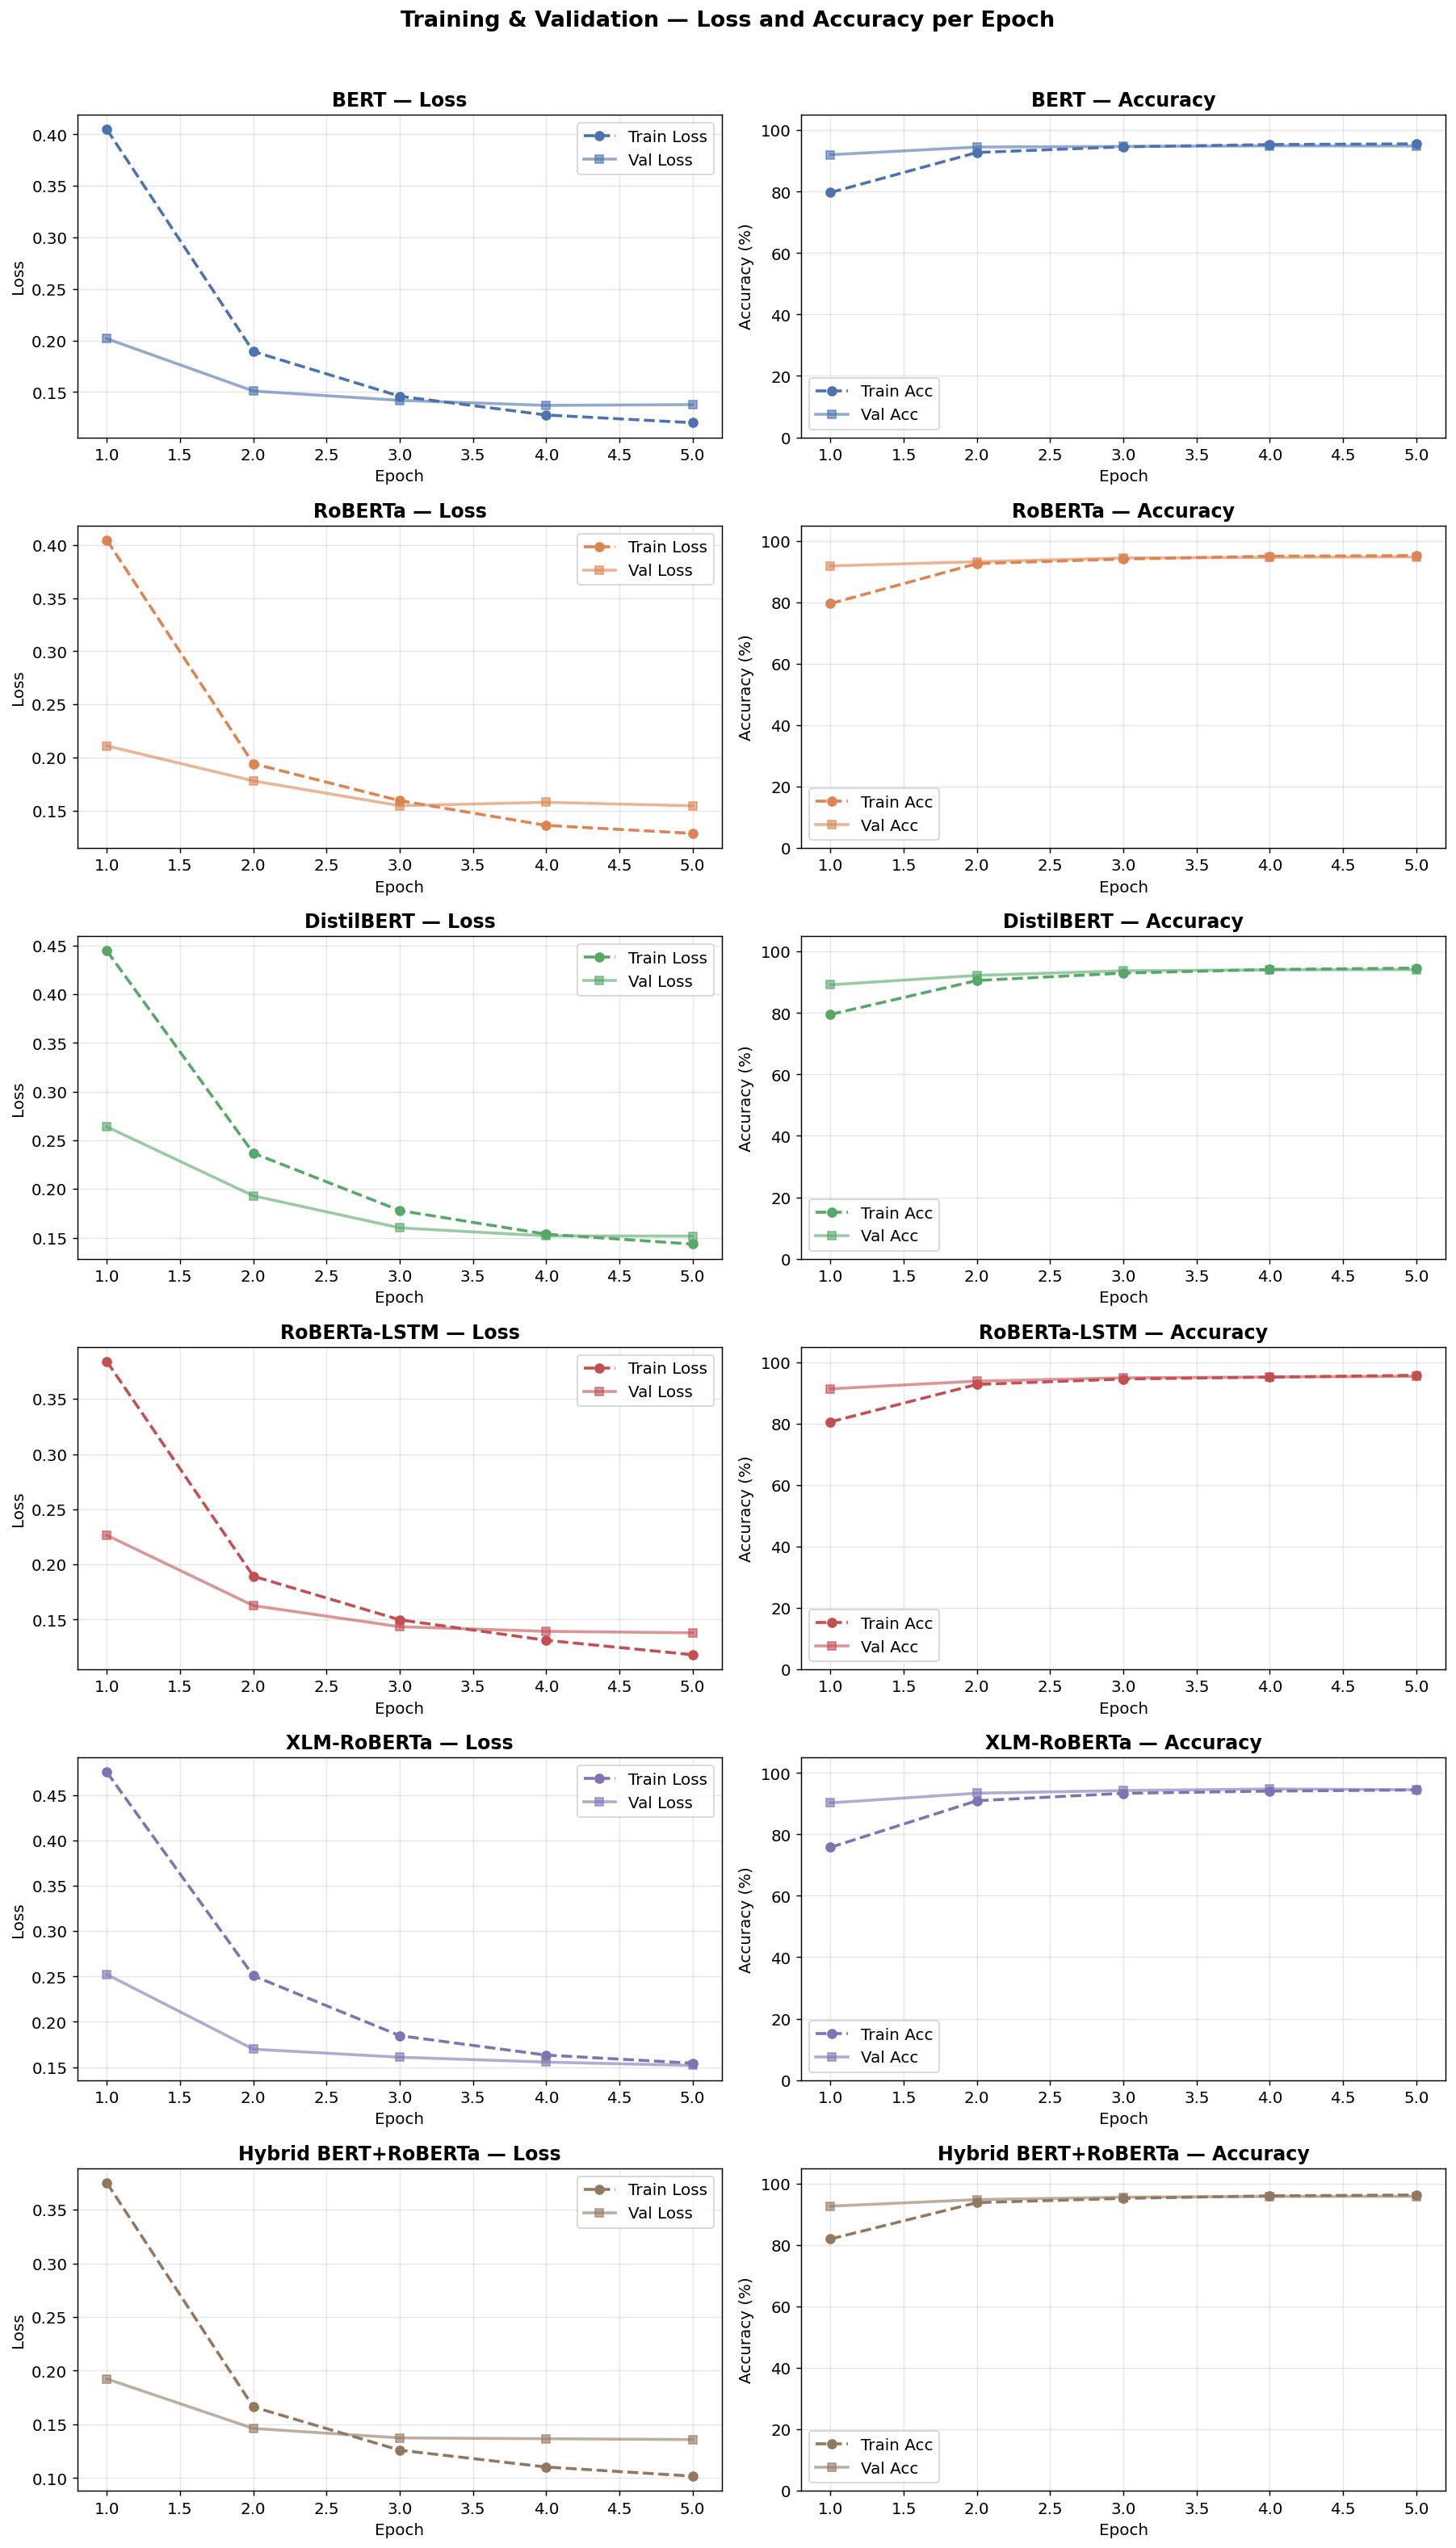

✅ Saved: plot1_learning_curves.png


In [14]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(len(results), 2, figsize=(14, 4 * len(results)))
fig.suptitle("Training & Validation — Loss and Accuracy per Epoch",
             fontsize=15, fontweight="bold", y=1.01)

for i, (name, res) in enumerate(results.items()):
    hist   = res["history"]
    epochs = range(1, len(hist["train_loss"]) + 1)
    col    = COLORS[i % len(COLORS)]

    ax_loss = axes[i][0]
    ax_acc  = axes[i][1]

    ax_loss.plot(epochs, hist["train_loss"], "o--", color=col,
                 label="Train Loss", linewidth=2)
    ax_loss.plot(epochs, hist["val_loss"],   "s-",  color=col,
                 label="Val Loss",   linewidth=2, alpha=0.6)
    ax_loss.set_title(f"{name} — Loss", fontweight="bold")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(epochs, [a*100 for a in hist["train_acc"]], "o--", color=col,
                label="Train Acc", linewidth=2)
    ax_acc.plot(epochs, [a*100 for a in hist["val_acc"]],   "s-",  color=col,
                label="Val Acc",   linewidth=2, alpha=0.6)
    ax_acc.set_title(f"{name} — Accuracy", fontweight="bold")
    ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.set_ylim(0, 105)
    ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot1_learning_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: plot1_learning_curves.png")


## 📉 Step 14 — Plot 2: Validation F1 / Precision / Recall per Epoch

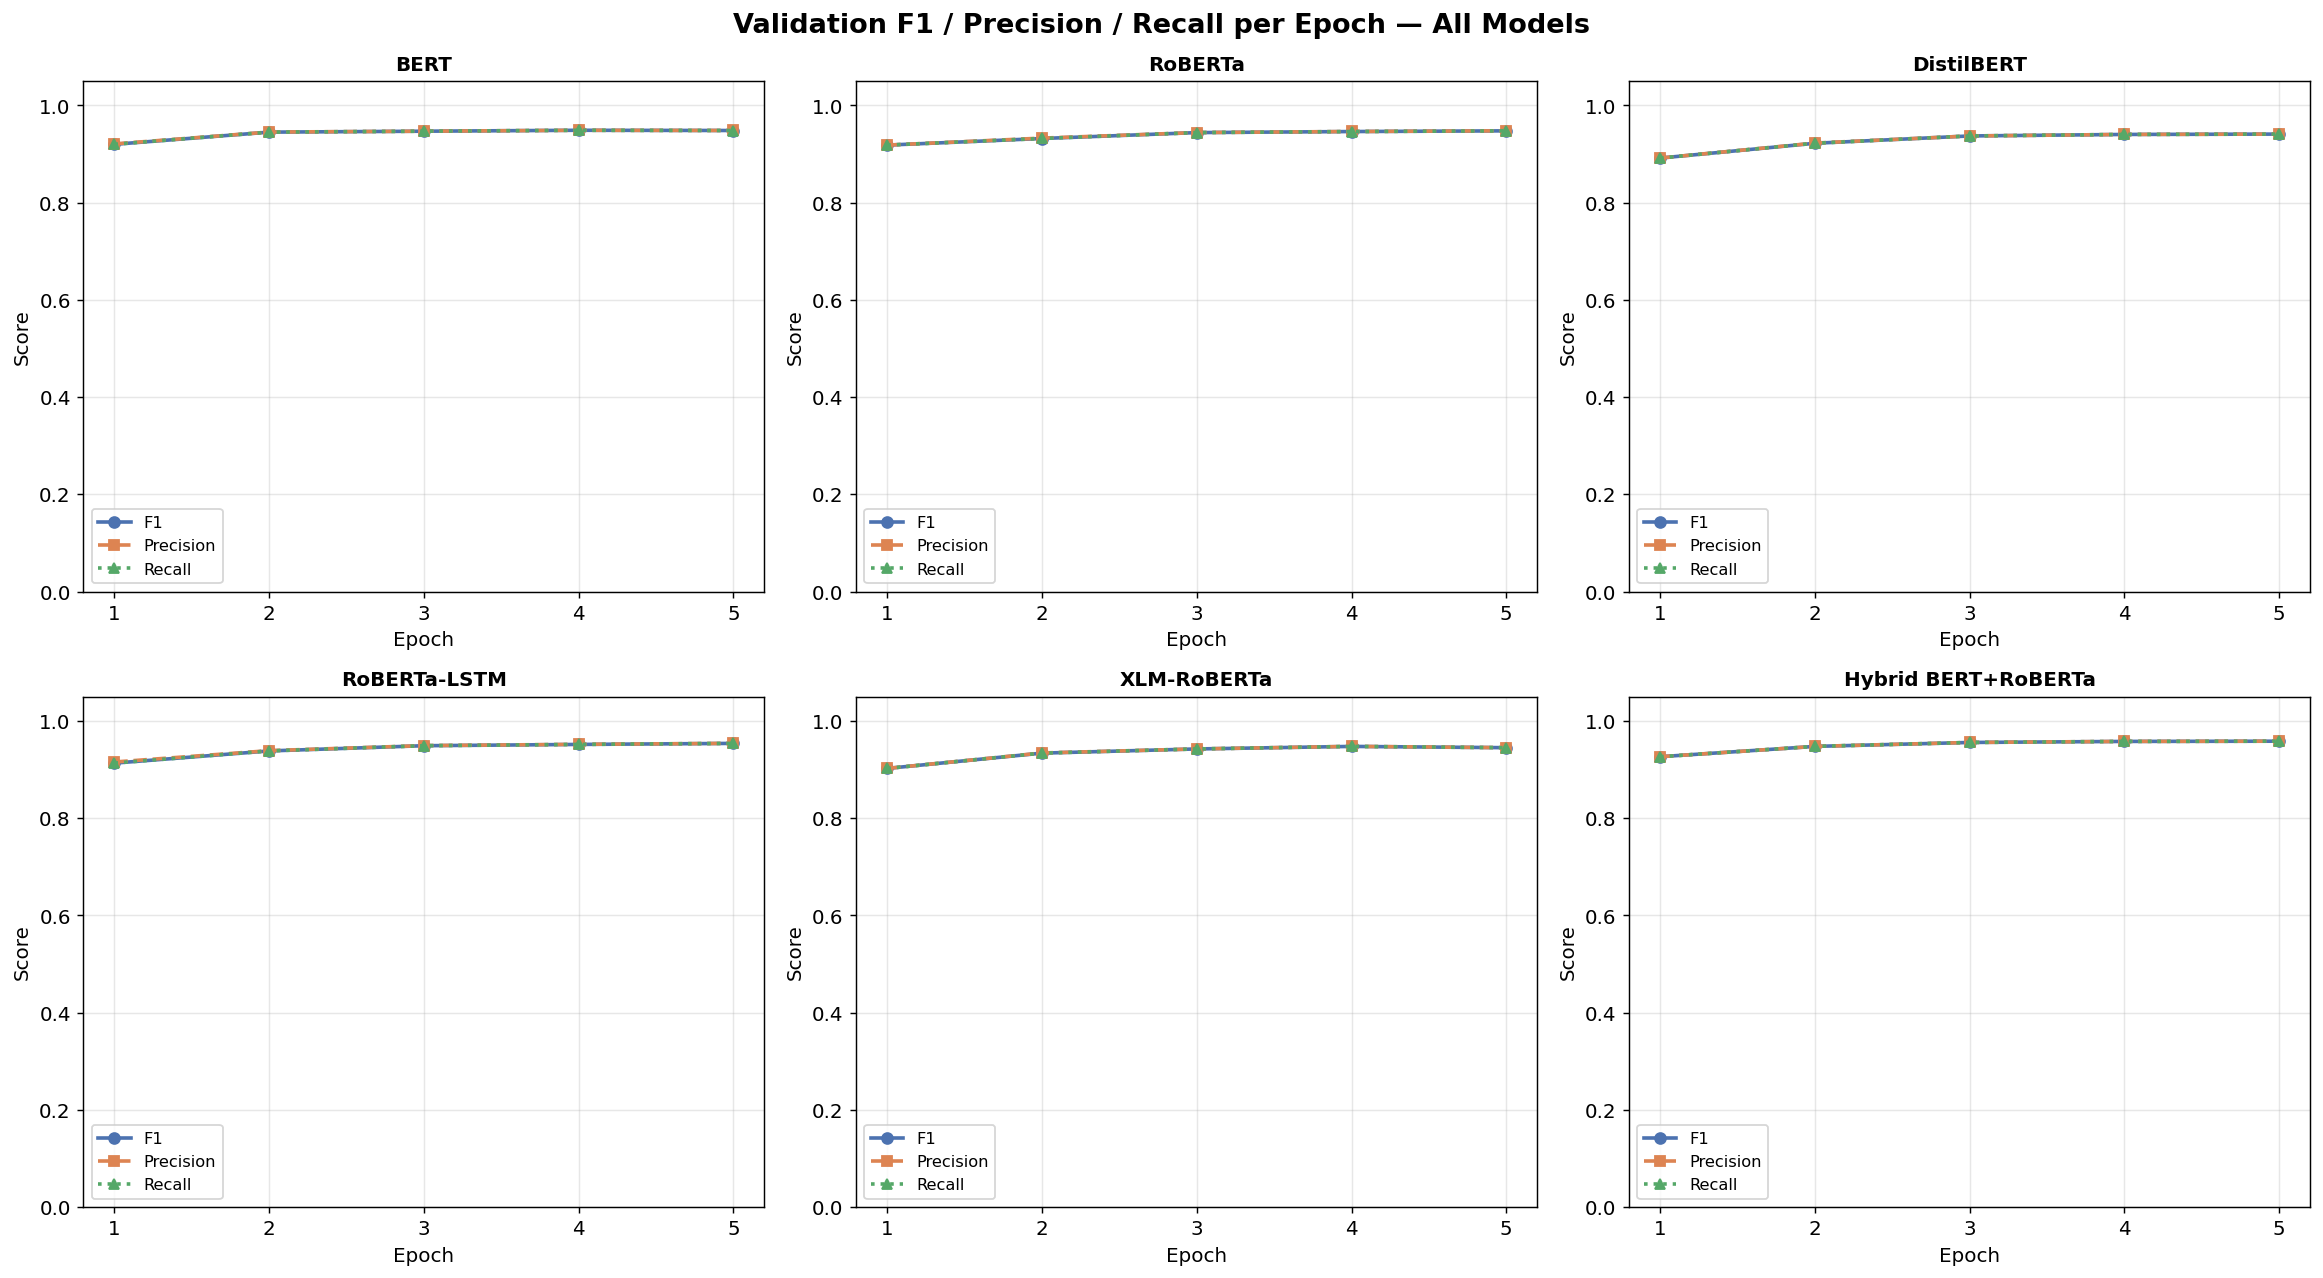

✅ Saved: plot2_val_f1_precision_recall.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Validation F1 / Precision / Recall per Epoch — All Models",
             fontsize=15, fontweight="bold")

for ax, (name, res) in zip(axes.flat, results.items()):
    hist   = res["history"]
    epochs = range(1, len(hist["val_f1"]) + 1)
    ax.plot(epochs, hist["val_f1"],        "o-",  color="#4C72B0", label="F1",        linewidth=2)
    ax.plot(epochs, hist["val_precision"], "s--", color="#DD8452", label="Precision", linewidth=2)
    ax.plot(epochs, hist["val_recall"],    "^:",  color="#55A868", label="Recall",    linewidth=2)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(list(epochs))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

for ax in axes.flat[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("plot2_val_f1_precision_recall.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: plot2_val_f1_precision_recall.png")


## 📊 Step 15 — Plot 3: Model Comparison Bar Chart

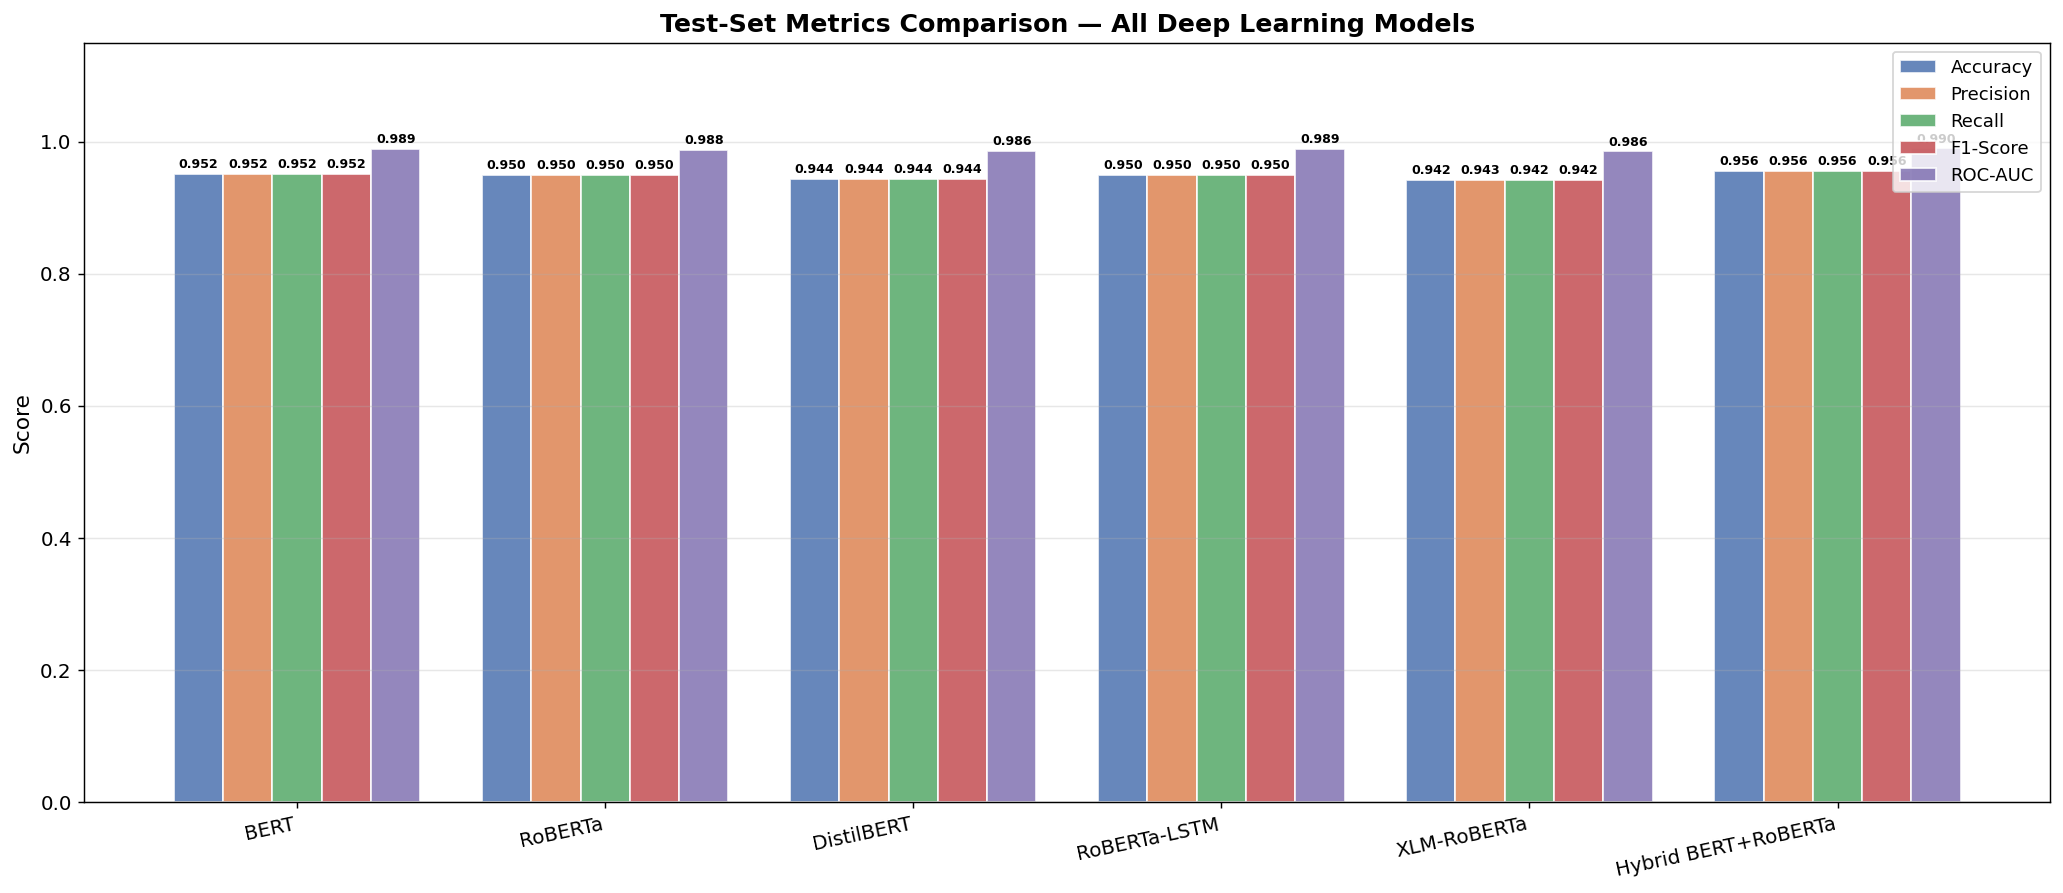

✅ Saved: plot3_model_comparison_bar.png


In [16]:
MODEL_NAMES  = list(final_met.keys())
metric_keys  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
metric_colors= ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

x     = np.arange(len(MODEL_NAMES))
width = 0.16

fig, ax = plt.subplots(figsize=(16, 7))

for i, (metric, col) in enumerate(zip(metric_keys, metric_colors)):
    vals = [float(final_met[m][metric]) for m in MODEL_NAMES]
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=col, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xticks(x + (len(metric_keys) - 1) * width / 2)
ax.set_xticklabels(MODEL_NAMES, fontsize=11, rotation=12, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Test-Set Metrics Comparison — All Deep Learning Models",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_model_comparison_bar.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: plot3_model_comparison_bar.png")


## 🔲 Step 16 — Plot 4: Confusion Matrices

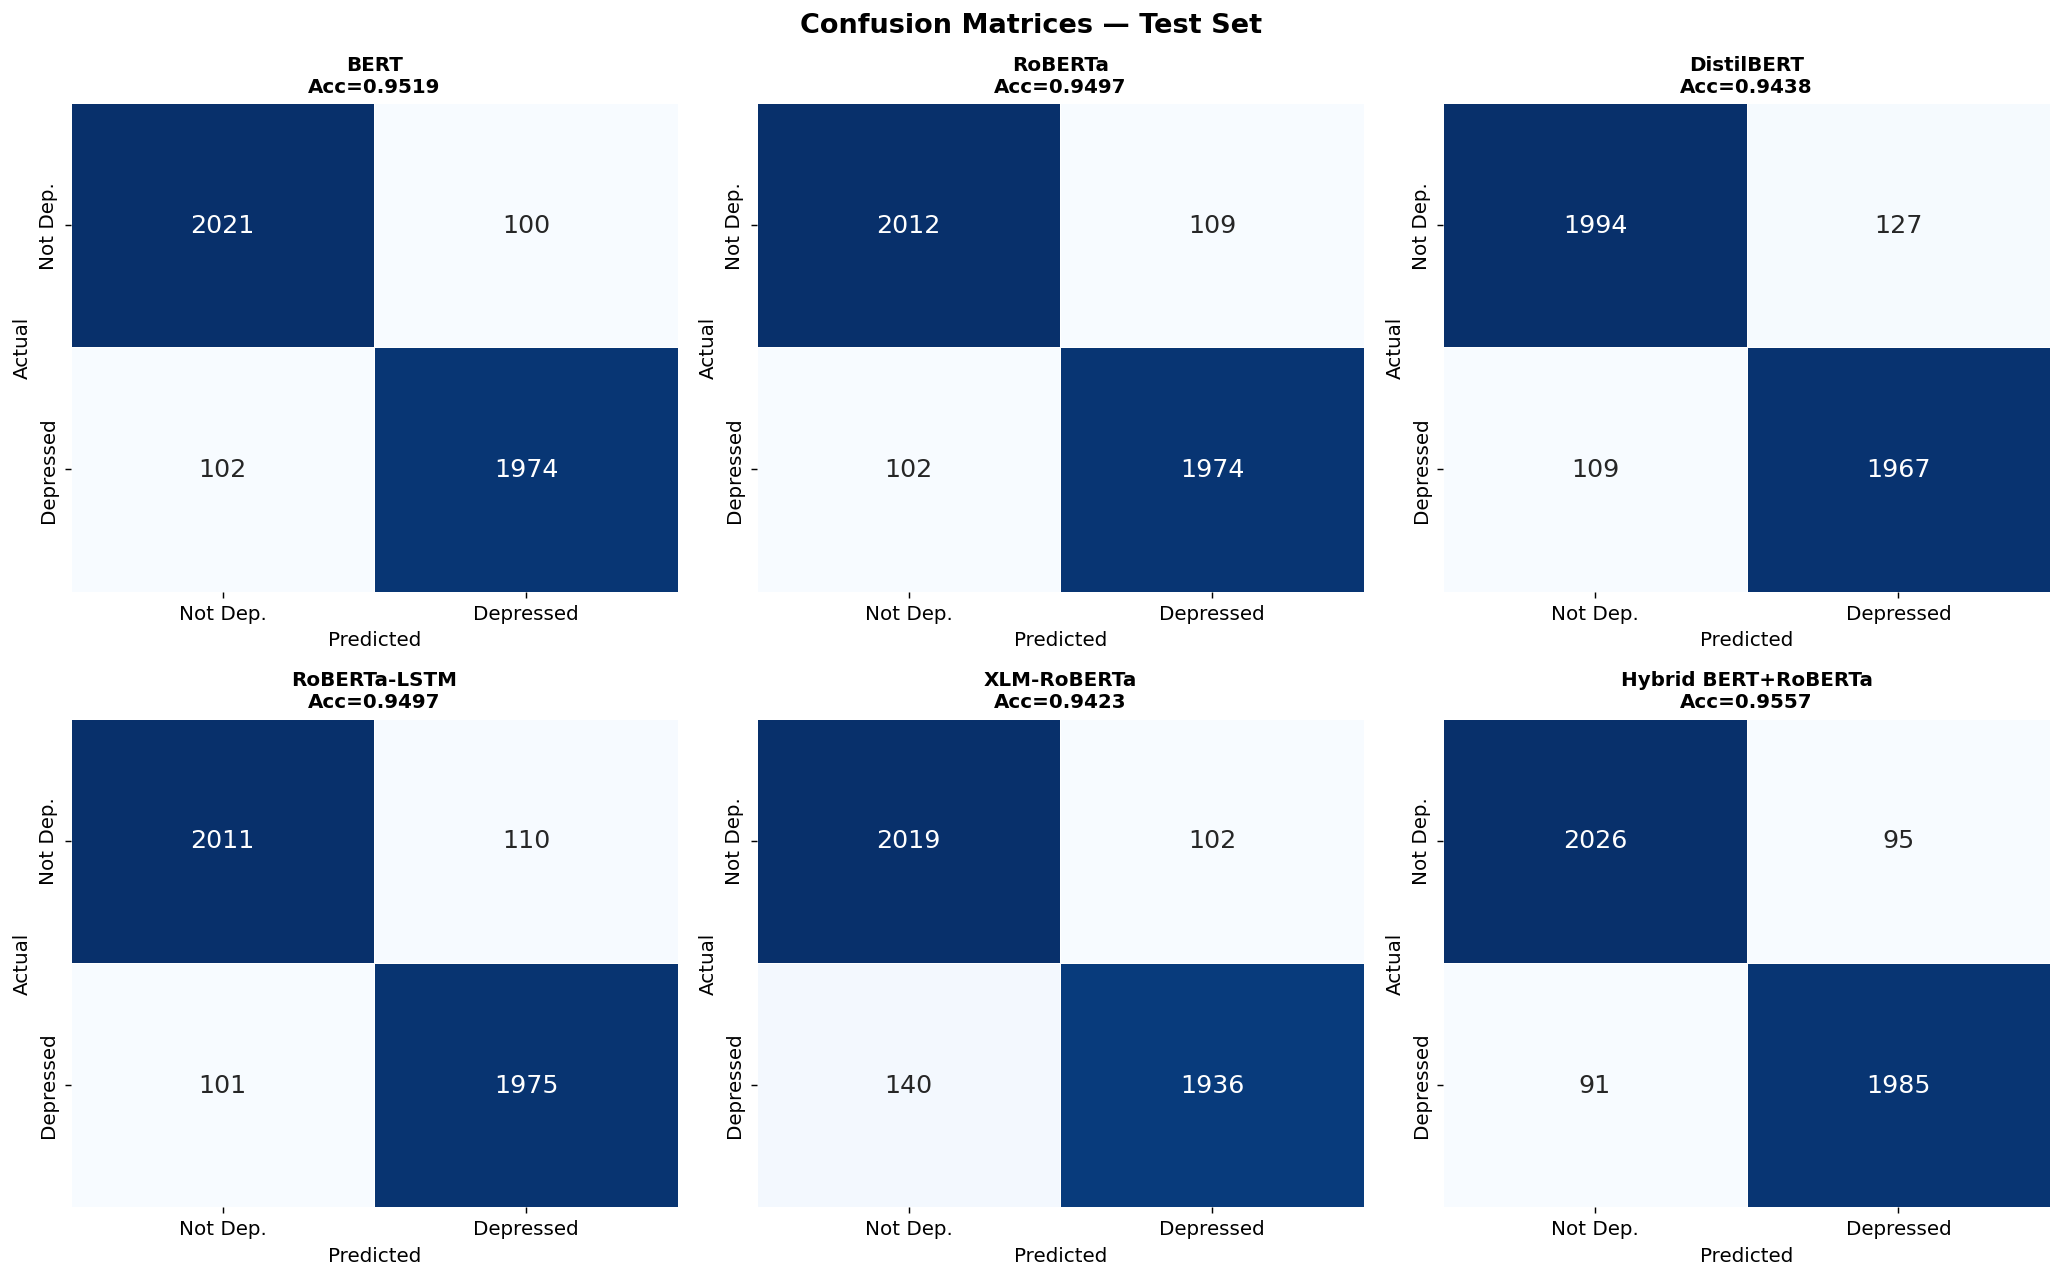

✅ Saved: plot4_confusion_matrices.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Confusion Matrices — Test Set", fontsize=15, fontweight="bold")

for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Dep.", "Depressed"],
                yticklabels=["Not Dep.", "Depressed"],
                linewidths=0.5, cbar=False, annot_kws={"size": 14})
    acc = final_met[name]["Accuracy"]
    ax.set_title(f"{name}\nAcc={acc:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

for ax in axes.flat[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("plot4_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: plot4_confusion_matrices.png")


## 📉 Step 17 — Plot 5: ROC Curves

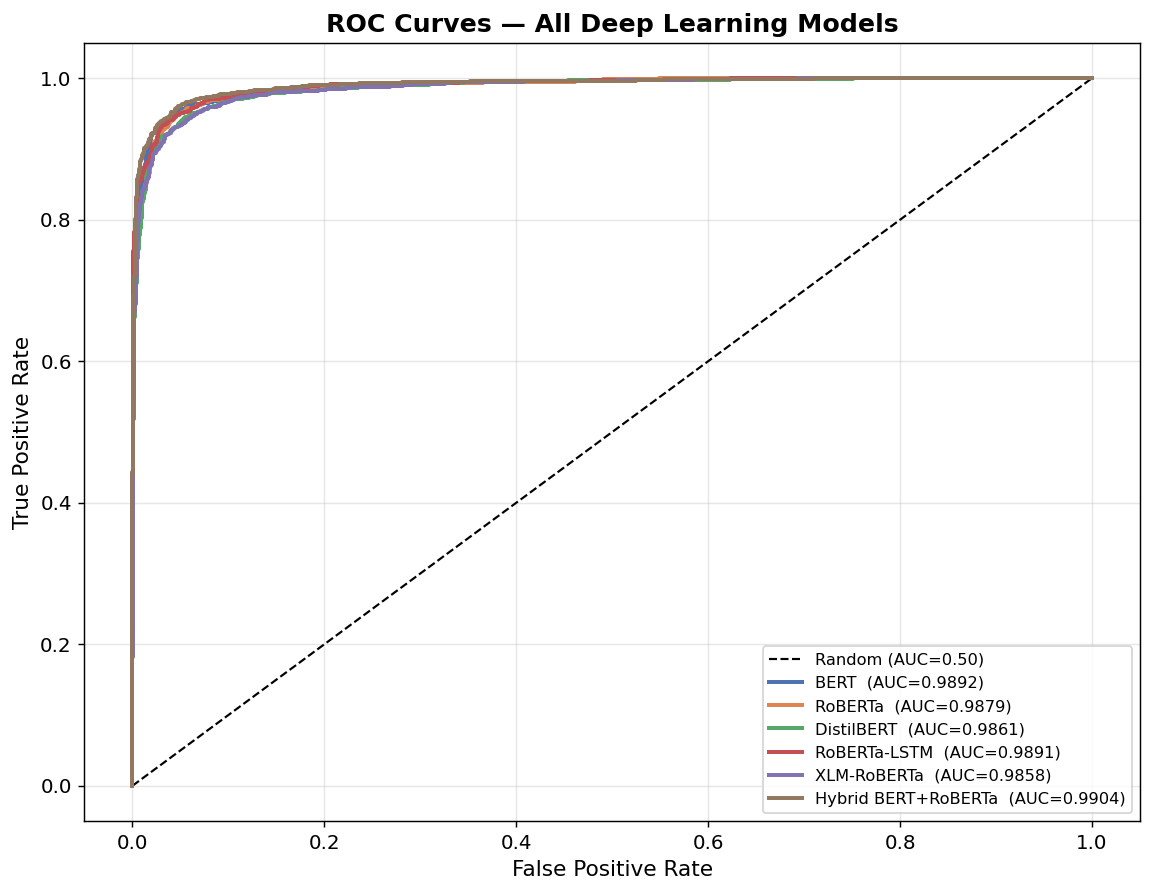

✅ Saved: plot5_roc_curves.png


In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random (AUC=0.50)")

for (name, res), col in zip(results.items(), COLORS):
    y_true = res["y_true"]
    y_prob = res["y_prob"]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = final_met[name]["ROC-AUC"]
    ax.plot(fpr, tpr, color=col, linewidth=2.2, label=f"{name}  (AUC={auc:.4f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Deep Learning Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot5_roc_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: plot5_roc_curves.png")


## 🕸️ Step 18 — Plot 6: Radar / Spider Chart

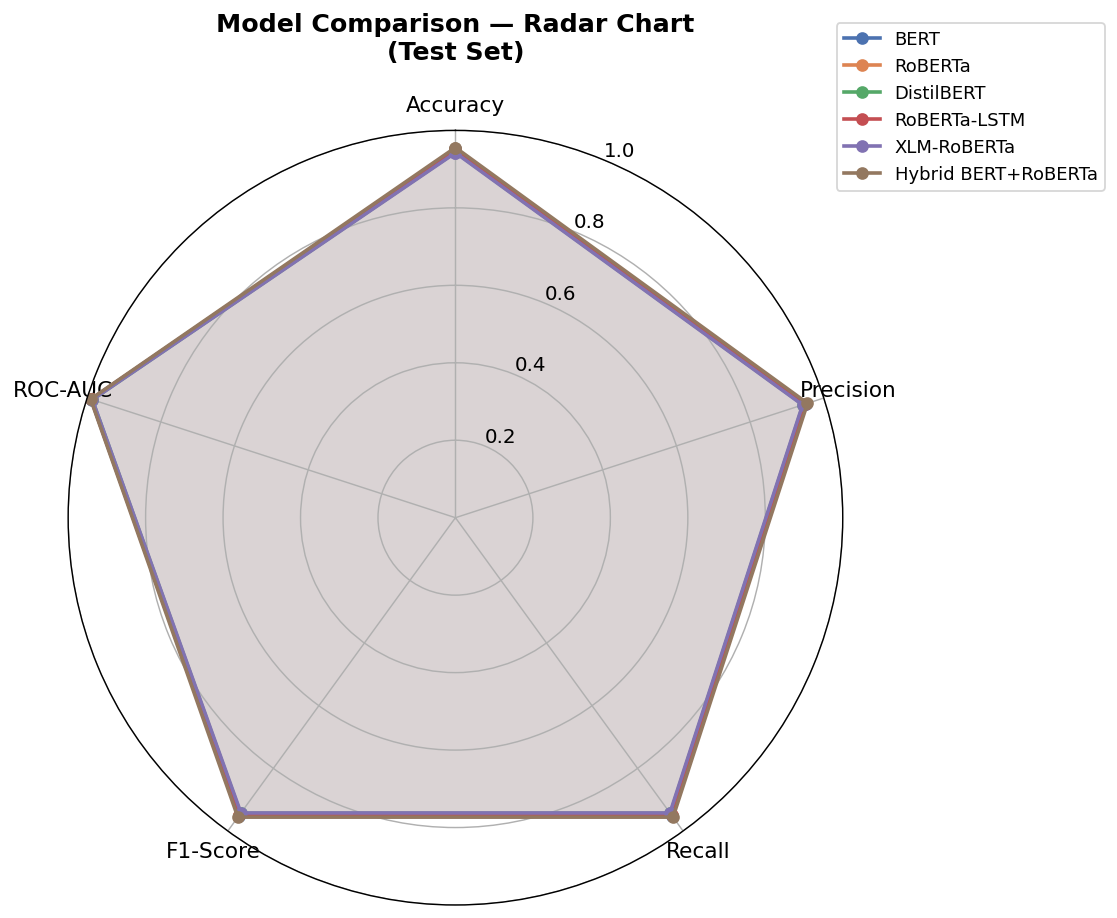

✅ Saved: plot6_radar_chart.png


In [19]:
from matplotlib.patches import FancyArrowPatch

cats   = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
N      = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12)
ax.set_ylim(0, 1)

for (name, met), col in zip(final_met.items(), COLORS):
    vals = [float(met[c]) for c in cats]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, color=col, label=name)
    ax.fill(angles, vals, alpha=0.06, color=col)

ax.set_title("Model Comparison — Radar Chart\n(Test Set)",
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig("plot6_radar_chart.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: plot6_radar_chart.png")


## 📉 Step 19 — Plot 7: Training Loss Comparison (All Models)

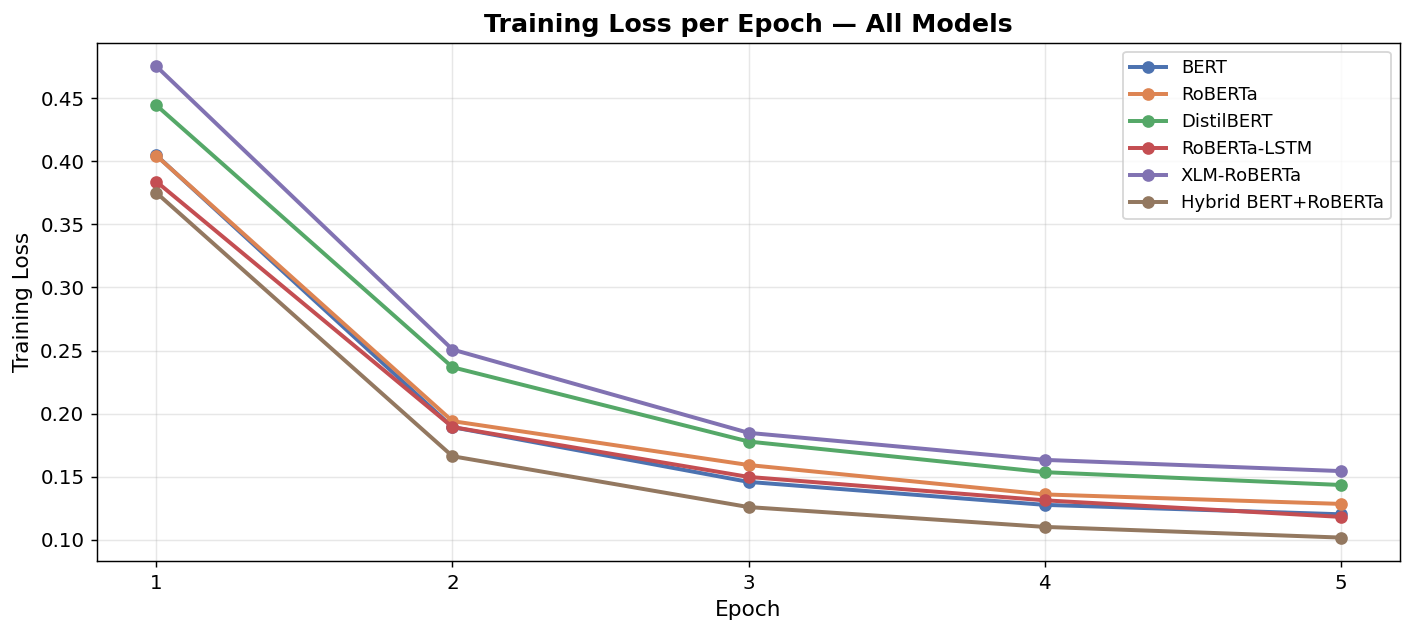

✅ Saved: plot7_train_loss_comparison.png


In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
for (name, res), col in zip(results.items(), COLORS):
    epochs = range(1, len(res["history"]["train_loss"]) + 1)
    ax.plot(epochs, res["history"]["train_loss"], marker="o",
            color=col, linewidth=2.2, label=name)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("Training Loss per Epoch — All Models", fontsize=14, fontweight="bold")
ax.set_xticks(range(1, EPOCHS + 1))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot7_train_loss_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: plot7_train_loss_comparison.png")


## 📋 Step 20 — Detailed Classification Reports

In [21]:
for name, res in results.items():
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    print(classification_report(
        res["y_true"], res["y_pred"],
        target_names=["Not Depressed", "Depressed"],
        zero_division=0
    ))


  BERT
               precision    recall  f1-score   support

Not Depressed       0.95      0.95      0.95      2121
    Depressed       0.95      0.95      0.95      2076

     accuracy                           0.95      4197
    macro avg       0.95      0.95      0.95      4197
 weighted avg       0.95      0.95      0.95      4197

  RoBERTa
               precision    recall  f1-score   support

Not Depressed       0.95      0.95      0.95      2121
    Depressed       0.95      0.95      0.95      2076

     accuracy                           0.95      4197
    macro avg       0.95      0.95      0.95      4197
 weighted avg       0.95      0.95      0.95      4197

  DistilBERT
               precision    recall  f1-score   support

Not Depressed       0.95      0.94      0.94      2121
    Depressed       0.94      0.95      0.94      2076

     accuracy                           0.94      4197
    macro avg       0.94      0.94      0.94      4197
 weighted avg       0.94   

## 🗺️ Step 21 — Plot 8: Metrics Heatmap

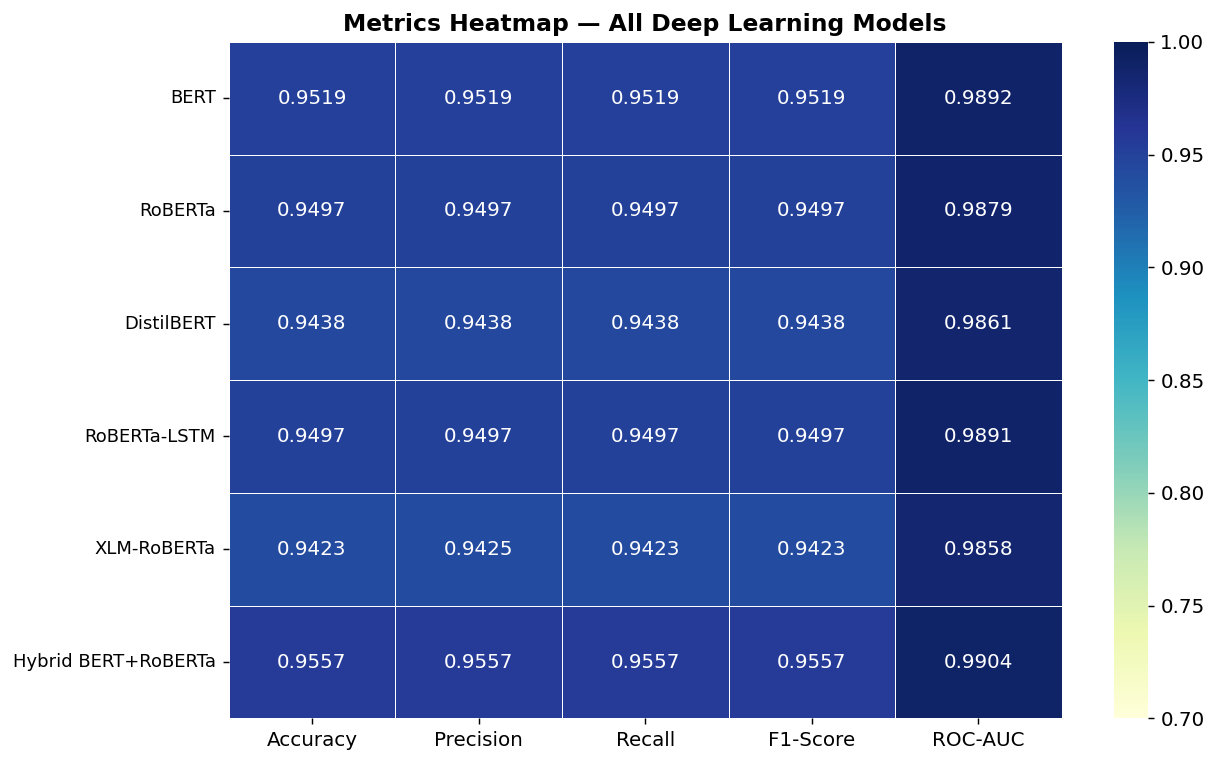

✅ Saved: plot8_metrics_heatmap.png


In [22]:
heat_df = pd.DataFrame(
    {m: {c: float(final_met[m][c]) for c in ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]}
     for m in final_met}
).T

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_df, annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, ax=ax, vmin=0.7, vmax=1.0,
            annot_kws={"size": 11})
ax.set_title("Metrics Heatmap — All Deep Learning Models",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig("plot8_metrics_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: plot8_metrics_heatmap.png")


## 💾 Step 22 — Download All Plots & Results

In [23]:
import zipfile, glob

# Save final metrics as CSV
pd.DataFrame(final_met).T.to_csv("deep_learning_metrics.csv")
print("✅ Saved: deep_learning_metrics.csv")

# Save results history as JSON
history_export = {
    name: {
        "history": res["history"],
        "final":   final_met[name]
    }
    for name, res in results.items()
}
with open("deep_learning_history.json", "w") as f:
    json.dump(history_export, f, indent=2)
print("✅ Saved: deep_learning_history.json")

# Zip everything
zip_path   = "depression_dl_results.zip"
plot_files = glob.glob("plot*.png") + ["deep_learning_metrics.csv", "deep_learning_history.json"]

with zipfile.ZipFile(zip_path, "w") as zf:
    for fp in plot_files:
        if os.path.exists(fp):
            zf.write(fp)
            print(f"  Added: {fp}")

print(f"\n📦 ZIP created: {zip_path}")

try:
    from google.colab import files
    files.download(zip_path)
    print("✅ Download started!")
except Exception:
    print(f"ℹ️  Not in Colab — ZIP saved locally as: {zip_path}")


✅ Saved: deep_learning_metrics.csv
✅ Saved: deep_learning_history.json
  Added: plot1_learning_curves.png
  Added: plot2_val_f1_precision_recall.png
  Added: plot3_model_comparison_bar.png
  Added: plot4_confusion_matrices.png
  Added: plot5_roc_curves.png
  Added: plot6_radar_chart.png
  Added: plot7_train_loss_comparison.png
  Added: plot8_metrics_heatmap.png
  Added: deep_learning_metrics.csv
  Added: deep_learning_history.json

📦 ZIP created: depression_dl_results.zip
ℹ️  Not in Colab — ZIP saved locally as: depression_dl_results.zip
